In [9]:
#!pip install matplotlib
#!pip install plotly
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [ ]:
from PIL import Image
img = Image.open("./kotik.jpg")

: 

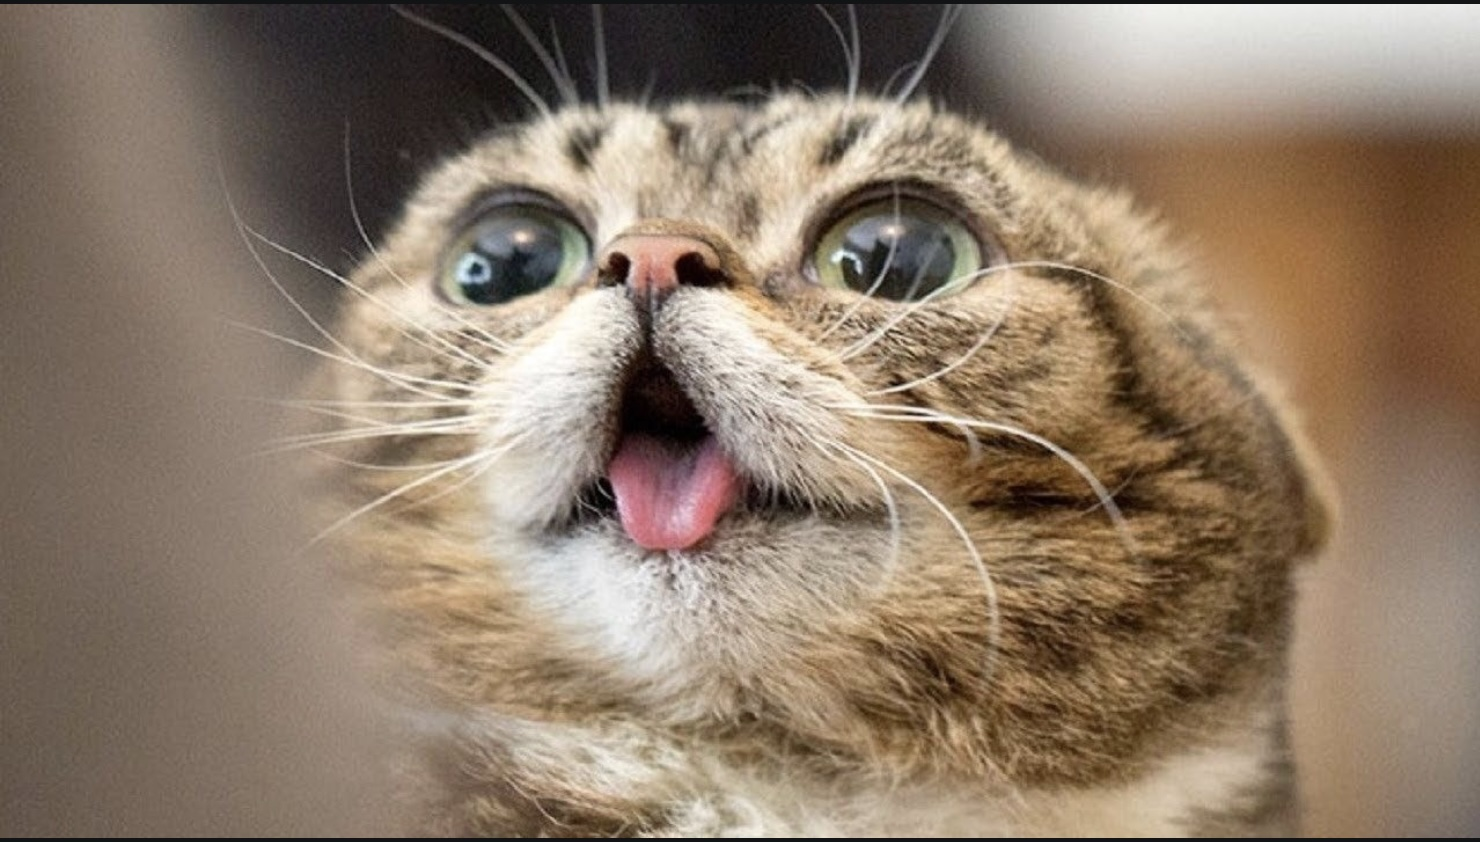

: 

In [ ]:
img

In [ ]:
img_array = np.array(img)
img_array

array([[[15, 19, 20],
        [16, 20, 21],
        [17, 21, 22],
        ...,
        [18, 19, 21],
        [18, 19, 21],
        [18, 19, 21]],

       [[17, 18, 20],
        [18, 19, 21],
        [18, 19, 21],
        ...,
        [18, 19, 21],
        [18, 19, 21],
        [18, 19, 21]],

       [[20, 18, 23],
        [19, 17, 22],
        [19, 17, 22],
        ...,
        [18, 20, 19],
        [18, 20, 19],
        [18, 20, 19]],

       ...,

       [[17, 18, 20],
        [18, 19, 21],
        [18, 19, 21],
        ...,
        [19, 19, 19],
        [19, 19, 19],
        [19, 19, 19]],

       [[16, 20, 19],
        [16, 20, 19],
        [16, 20, 21],
        ...,
        [18, 19, 21],
        [18, 19, 21],
        [18, 19, 21]],

       [[15, 21, 19],
        [15, 21, 19],
        [15, 21, 21],
        ...,
        [18, 19, 21],
        [18, 19, 21],
        [18, 19, 21]]], dtype=uint8)

: 

In [10]:
gs = img_array[:, :, 0] * 0.299 + img_array[:, :, 1] * 0.587 + img_array[:, :, 2] * 0.114
gs

array([[17.918, 18.918, 19.918, ..., 18.929, 18.929, 18.929],
       [17.929, 18.929, 18.929, ..., 18.929, 18.929, 18.929],
       [19.168, 18.168, 18.168, ..., 19.288, 19.288, 19.288],
       ...,
       [17.929, 18.929, 18.929, ..., 19.   , 19.   , 19.   ],
       [18.69 , 18.69 , 18.918, ..., 18.929, 18.929, 18.929],
       [18.978, 18.978, 19.206, ..., 18.929, 18.929, 18.929]])

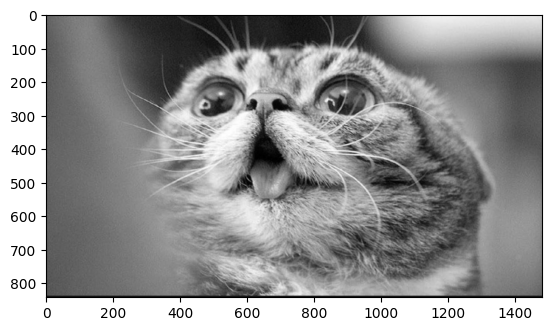

In [11]:
import matplotlib.pyplot as plt
plt.imshow(gs,cmap='gray', vmin=0, vmax=255)

In [12]:
type(gs), gs.shape

(numpy.ndarray, (842, 1480))

(<matplotlib.image.AxesImage at 0x1322ef080>, 185.84, 'kbytes')

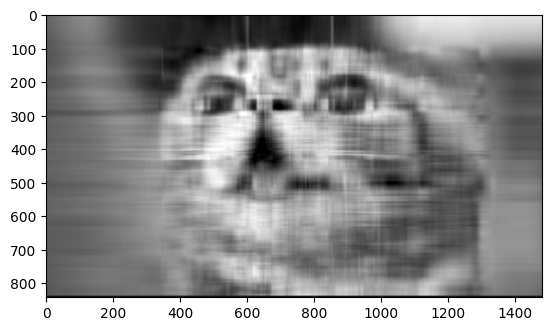

In [36]:

def compress_svd(image, k):
    # Полное SVD
    u, s, vt = np.linalg.svd(image, full_matrices=False)
    # Сжатие
    u = u[:, :k]
    s = s[:k]
    vt = vt[:k, :]
    size_compressed = u.nbytes + s.nbytes + vt.nbytes
    # Восстановление
    return u @ np.diag(s) @ vt, size_compressed
    #np.diag(s) превращает вектор сингулярных значений в диагональную матрицу, 

plt.imshow(compress_svd(gs, 10)[0],cmap='gray', vmin=0, vmax=255), compress_svd(gs, 10)[1]/1000,"kbytes"

In [37]:
def relative_error_svd(A, A_k):
    """
    Вычисляет относительную ошибку сжатия изображения SVD по формуле ||A - A_k||_F/||A||_F.
    """
    # Вычисляем Фробениусову норму разности ||A - A_k||_F
    error_norm = np.linalg.norm(A - A_k, ord='fro')
    
    # Вычисляем Фробениусову норму оригинальной матрицы ||A||_F
    original_norm = np.linalg.norm(A, ord='fro')

    return error_norm / original_norm

relative_error_svd(gs, compress_svd(gs, 10)[0])

0.1273100574849846

In [38]:
%%time
#нарисуй график зависимости относительной ошибки relative_error_svd(A, A_k)  от количества сингулярных значений k
m, n = gs.shape
k_range = np.arange(1, min(m, n) + 1, 10)

relative_errors = []
for k in k_range:
    relative_errors.append(relative_error_svd(gs, compress_svd(gs, k)[0]))

CPU times: user 8min 36s, sys: 2min 12s, total: 10min 48s
Wall time: 59.4 s


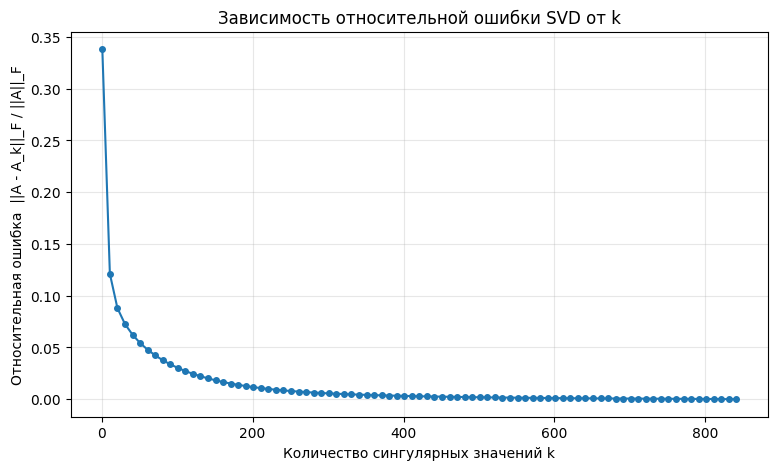

In [39]:
errors = np.array(relative_errors)
plt.figure(figsize=(9, 5))
plt.plot(k_range, errors, 'o-', markersize=4, linewidth=1.5)
plt.xlabel('Количество сингулярных значений k')
plt.ylabel('Относительная ошибка  ||A - A_k||_F / ||A||_F')
plt.title('Зависимость относительной ошибки SVD от k')
plt.grid(True, alpha=0.3)
plt.show()

185.84 kb


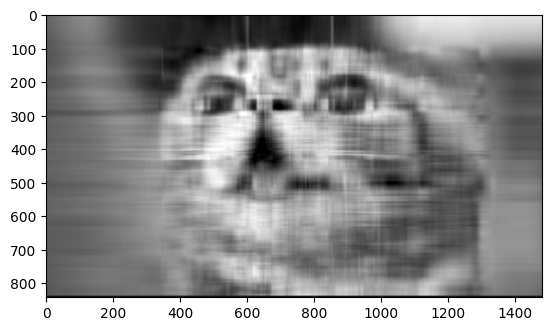

In [40]:
# три примера сжатия изображения с разным количеством сингулярных значений 
# (сильное сжатие, средняя степень сжатия и слабое сжатие) и оценка,
# сколько элементов надо хранить для восстановления изображения для каждого
# из трёх значений количества сингулярных значений.
k=10
print(compress_svd(gs, k)[1]/1000, "kb")
plt.imshow(compress_svd(gs, k)[0],cmap='gray', vmin=0, vmax=255)

929.2 kb


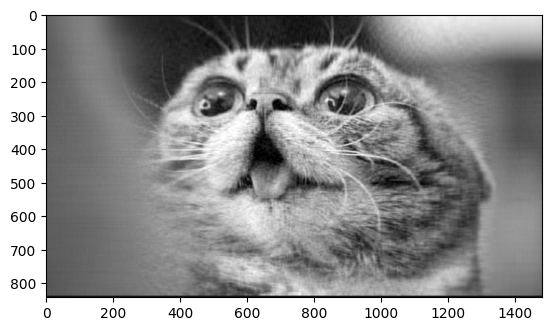

In [41]:
k=50
print(compress_svd(gs, k)[1]/1000, "kb")
plt.imshow(compress_svd(gs, k)[0],cmap='gray', vmin=0, vmax=255)

3716.8 kb


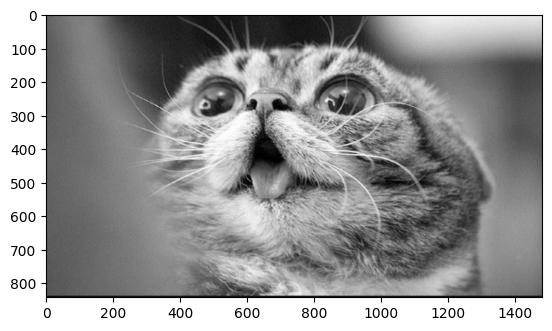

In [43]:
k=200
print(compress_svd(gs, k)[1]/1000, "kb")
plt.imshow(compress_svd(gs, k)[0],cmap='gray', vmin=0, vmax=255)